# 04 — Análise de Correspondência Múltipla (Cap. 6.4)

**Método:** MCA via `prince`

In [1]:
import pandas as pd
import numpy as np
import prince
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.1)
df = pd.read_csv('../data/processed/corpus_dataset.csv')
df['endurec_level'] = pd.qcut(df['purificacao_composto'], q=3, labels=['baixo','medio','alto'])
mca_cols = ['country', 'period_norm', 'medium_norm', 'regime_iconocratico', 'endurec_level']
df_mca = df[mca_cols].copy()
country_counts = df_mca['country'].value_counts()
df_mca.loc[df_mca['country'].isin(country_counts[country_counts < 4].index), 'country'] = 'Other'
df_mca = df_mca.dropna()
print(f"MCA input: {len(df_mca)} itens, {len(mca_cols)} variáveis")
for col in mca_cols:
    print(f"  {col}: {df_mca[col].nunique()} categorias")

MCA input: 89 itens, 5 variáveis
  country: 10 categorias
  period_norm: 9 categorias
  medium_norm: 9 categorias
  regime_iconocratico: 3 categorias
  endurec_level: 3 categorias


## 4.1 Inércia explicada

In [2]:
mca = prince.MCA(n_components=3, random_state=42)
mca = mca.fit(df_mca)
print("Inércia explicada:")
for i, (eig, pct) in enumerate(zip(mca.eigenvalues_, mca.percentage_of_variance_)):
    print(f"  Dim {i+1}: eigenvalue = {eig:.4f}, inércia = {pct:.1f}%")
print(f"  Total (3 dims): {sum(mca.percentage_of_variance_[:3]):.1f}%")

Inércia explicada:
  Dim 1: eigenvalue = 0.5169, inércia = 8.9%
  Dim 2: eigenvalue = 0.4901, inércia = 8.4%
  Dim 3: eigenvalue = 0.4458, inércia = 7.7%
  Total (3 dims): 25.0%


/Users/ana/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/ana/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/ana/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/ana/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/ana/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/ana/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/ana/Library

## 4.2 Biplot de categorias

/Users/ana/Library/Python/3.9/lib/python/site-packages/prince/ca.py:222: RuntimeWarning: divide by zero encountered in matmul
  data=X @ sparse.diags(self.row_masses_.to_numpy() ** -0.5) @ self.svd_.U,
/Users/ana/Library/Python/3.9/lib/python/site-packages/prince/ca.py:222: RuntimeWarning: overflow encountered in matmul
  data=X @ sparse.diags(self.row_masses_.to_numpy() ** -0.5) @ self.svd_.U,
/Users/ana/Library/Python/3.9/lib/python/site-packages/prince/ca.py:222: RuntimeWarning: invalid value encountered in matmul
  data=X @ sparse.diags(self.row_masses_.to_numpy() ** -0.5) @ self.svd_.U,


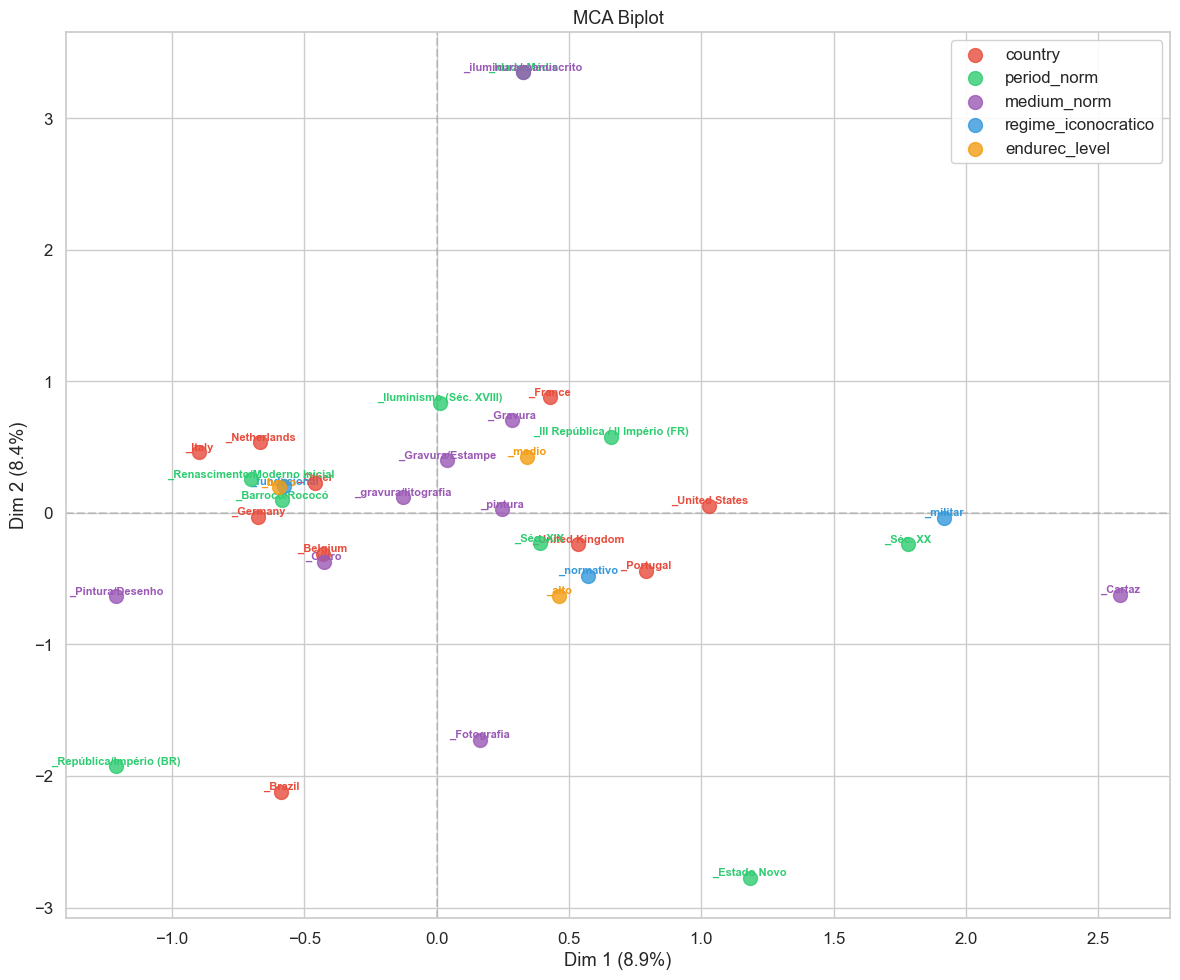

In [3]:
col_coords = mca.column_coordinates(df_mca)
var_colors = {'country': '#e74c3c', 'period_norm': '#2ecc71', 'medium_norm': '#9b59b6', 'regime_iconocratico': '#3498db', 'endurec_level': '#f39c12'}
fig, ax = plt.subplots(figsize=(12, 10))
for var in mca_cols:
    mask = col_coords.index.str.startswith(var + '_')
    coords = col_coords[mask]
    ax.scatter(coords[0], coords[1], s=100, color=var_colors[var], label=var, zorder=5, alpha=0.8)
    for idx, row in coords.iterrows():
        label = idx.replace(var + '_', '')
        ax.annotate(label, (row[0], row[1]), fontsize=8, ha='center', va='bottom', color=var_colors[var], fontweight='bold')
ax.axhline(0, color='grey', ls='--', alpha=0.3)
ax.axvline(0, color='grey', ls='--', alpha=0.3)
ax.set_xlabel(f"Dim 1 ({mca.percentage_of_variance_[0]:.1f}%)")
ax.set_ylabel(f"Dim 2 ({mca.percentage_of_variance_[1]:.1f}%)")
ax.set_title('MCA Biplot')
ax.legend(loc='upper right', framealpha=0.9)
plt.tight_layout()
plt.savefig('../data/processed/fig_09_mca_biplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.3 Itens individuais no espaço MCA

/Users/ana/Library/Python/3.9/lib/python/site-packages/prince/ca.py:159: RuntimeWarning: divide by zero encountered in matmul
  data=X @ sparse.diags(self.col_masses_.to_numpy() ** -0.5) @ self.svd_.V.T,
/Users/ana/Library/Python/3.9/lib/python/site-packages/prince/ca.py:159: RuntimeWarning: overflow encountered in matmul
  data=X @ sparse.diags(self.col_masses_.to_numpy() ** -0.5) @ self.svd_.V.T,
/Users/ana/Library/Python/3.9/lib/python/site-packages/prince/ca.py:159: RuntimeWarning: invalid value encountered in matmul
  data=X @ sparse.diags(self.col_masses_.to_numpy() ** -0.5) @ self.svd_.V.T,


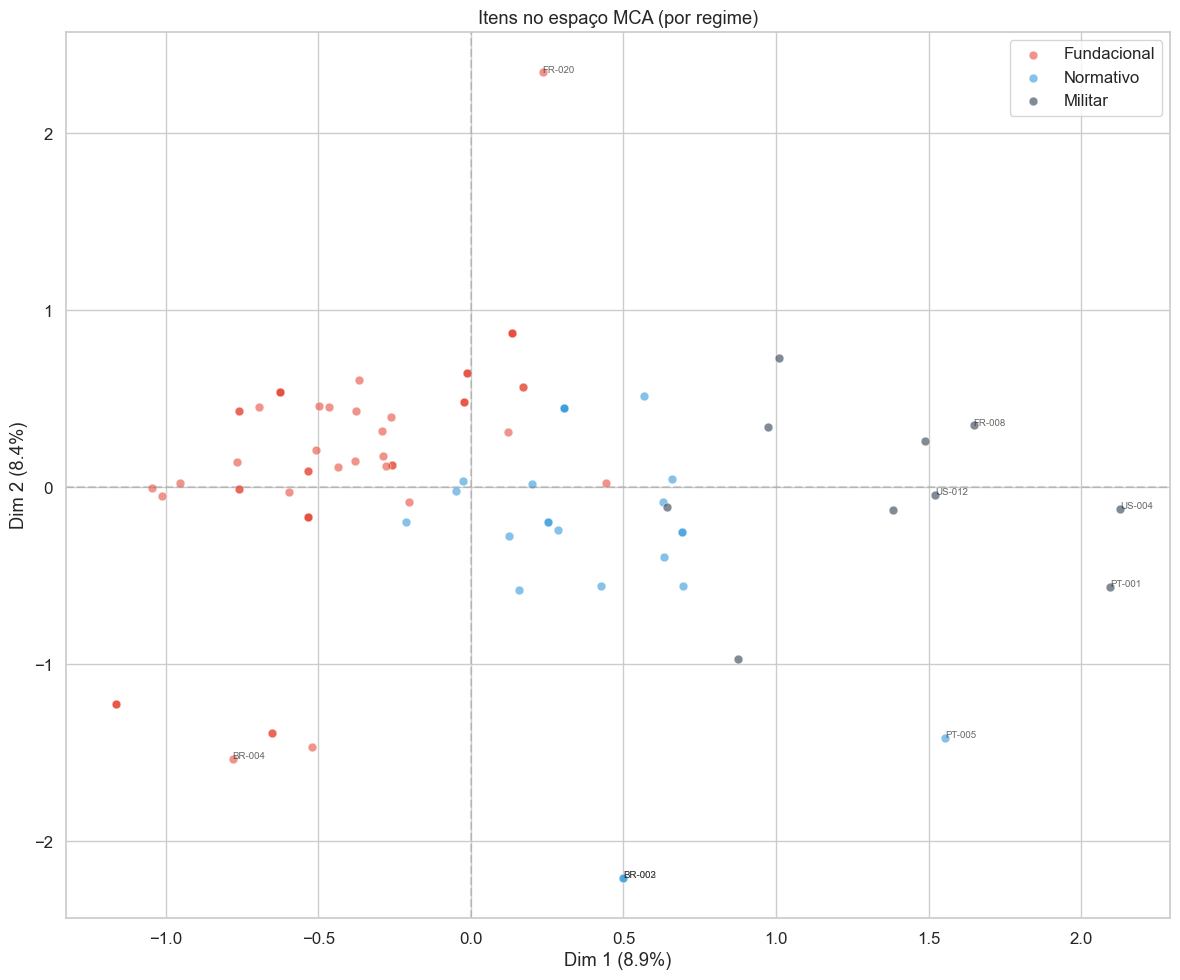

Top 10 itens extremos:
  FR-020               regime=fundacional  dist=2.36
  BR-002               regime=normativo    dist=2.26
  BR-003               regime=normativo    dist=2.26
  PT-001               regime=militar      dist=2.17
  US-004               regime=militar      dist=2.13
  PT-005               regime=normativo    dist=2.10
  BR-004               regime=fundacional  dist=1.72
  BR-005               regime=fundacional  dist=1.69
  BR-006               regime=fundacional  dist=1.69
  BR-010               regime=fundacional  dist=1.69


In [4]:
row_coords = mca.row_coordinates(df_mca)
row_coords['regime'] = df_mca['regime_iconocratico'].values
row_coords['id'] = df.loc[df_mca.index, 'id'].values
regime_palette = {'fundacional': '#e74c3c', 'normativo': '#3498db', 'militar': '#2c3e50'}
fig, ax = plt.subplots(figsize=(12, 10))
for regime, color in regime_palette.items():
    mask = row_coords['regime'] == regime
    sub = row_coords[mask]
    ax.scatter(sub[0], sub[1], c=color, label=regime.capitalize(), alpha=0.6, s=40, edgecolors='white', linewidth=0.5)
threshold = row_coords[[0, 1]].abs().max(axis=1).quantile(0.9)
outliers = row_coords[row_coords[[0, 1]].abs().max(axis=1) > threshold]
for _, row in outliers.iterrows():
    ax.annotate(row['id'], (row[0], row[1]), fontsize=7, alpha=0.7)
ax.axhline(0, color='grey', ls='--', alpha=0.3)
ax.axvline(0, color='grey', ls='--', alpha=0.3)
ax.set_xlabel(f"Dim 1 ({mca.percentage_of_variance_[0]:.1f}%)")
ax.set_ylabel(f"Dim 2 ({mca.percentage_of_variance_[1]:.1f}%)")
ax.set_title('Itens no espaço MCA (por regime)')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/fig_10_mca_individuals.png', dpi=150, bbox_inches='tight')
plt.show()
row_coords['dist'] = np.sqrt(row_coords[0]**2 + row_coords[1]**2)
print("Top 10 itens extremos:")
for _, r in row_coords.nlargest(10, 'dist').iterrows():
    print(f"  {r['id']:20s} regime={r['regime']:12s} dist={r['dist']:.2f}")